# Model Training Notebook

This is the Jupyter notebook where both the cross-validation and final training + evaluation were run. The snippets in this notebook call other modules in this directory that did the heavy lifting/automation for these steps (e.g. [keras_utility_classes.py](keras_utility_classes.py)). There are analogous notebooks for the other two model architectures, which facilitated training all three in parallel using multiple systems. **There are two important things to note about these notebooks:**

+ During the project there was an issue with the code for my initial cross-validation which led to some metrics not being logged properly. As such, even though I had completed cross-validation, I did not have a few of the metrics I wanted to put into the plots in the manuscript/final report (i.e. supplemental Figure 13). I re-ran cross-validation towards the end of the project on the same CV folds to get some of these metrics for the report. This is why the dates/timestamps for cross-validation in these files are later than the those of the final training run.

+ A few cell outputs in these notebooks stop mid-epoch. This was due to a bug where the Jupyter notebook would occasionally lose communication with the main process and stop updating, despite the fact that training continued successfully to the end (as indicated by fully completed logs of all epochs and corresponding model weights).

### Make and save the folds used for cross-validation comparison of models

In [ ]:
# import keras_utility_classes as kutils
# from preparation_1 import structural_profiles
# from get_normalization_params_5 import load_json

# # Load the estimated class weights
# class_weights = f'{structural_profiles}class_weights.json'
# class_weights = load_json(class_weights, verbose=True)

# # # Initialize a trainer object
# trainer = kutils.TrainingRun(class_weights = class_weights,
#                              class_encoding = {'control_exons' : 0, 
#                                                'control_introns_intergenic' : 0, 
#                                                'control_introns_intron' : 0, 
#                                                'intron-exon' : 1, 
#                                                'exon-intron' : 2})

# trainer.get_CV_folds(N_folds=5, save_dir='./CV_folds/')

# TCN cross validation

In [2]:
import keras_models as my_models

model_init = {'n_filters' : 256, # alternative: 128
              'kernel_size': 3, 
              'dilations' : (1, 2, 6, 10),
              'dense_layer_dims' : [256]}

model = my_models.TCN_classifier((77,28), 3, **model_init, print_summary=True)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 77, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_1 (TCN)                     │ (None, 256)            │     1,407,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473,795 (5.62 MB)

 Trainable params: 1,473,795 (5.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import keras_models as my_models
import keras_utility_classes as kutils
from preparation_1 import structural_profiles
from get_normalization_params_5 import load_json


## Load the estimated class weights that factor into the loss function
class_weights = f'{structural_profiles}class_weights.json'
class_weights = load_json(class_weights, verbose=True)

# Define where the training results and logs will be saved
project_folder = './TCN_best_cv/'
base_name = 'TCN'
kutils.check_make_dir(project_folder)

## Initialize a trainer object with the class weights and encoding dictionaries
trainer = kutils.TrainingRun(class_weights = class_weights,
                             class_encoding = {'control_exons' : 0, 
                                               'control_introns_intergenic' : 0, 
                                               'control_introns_intron' : 0, 
                                               'intron-exon' : 1, 
                                               'exon-intron' : 2})

# Name constructor function for the model type to use (one found in keras_models) and define required hyperparameters
model_creator = my_models.TCN_classifier
model_init = {'n_filters' : 256,
              'kernel_size': 3, 
              'dilations' : (1, 2, 6, 10),
              'dense_layer_dims' : [256],
              'print_summary' : True}

# Run the model training in 5-fold cross validation mode, saving results and best models from each run
trainer.execute_training_run(model_creator=model_creator, 
                             model_args=model_init,
                             saves_base_dir = project_folder, 
                             base_name = base_name,
                             batch_size=64,
                             max_epochs=10,
                             patience=0, 
                             run_type='cross_validation',
                             N_folds=5, 
                             folds_dir='./CV_folds/',
                             lr_decay=False,
                             lr=0.0002, # 1/5 default learning rate
                             plot_results=False) 

2025-09-28 12:33:34.533103: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-28 12:33:35.399664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-28 12:33:37.620845: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


load_json: Loaded ./3_Physicochemical_Profiles/class_weights.json.
check_make_dir(): made ./TCN_best_cv/.
TrainingRun(): Loading neccesary .json and .npy data files...
write_json_pretty: Wrote ./TCN_best_cv/training_call.json.
execute_training_run(): loading cross-validation splits from files in ./CV_folds/...
execute_training_run(): it appears that no folds have been completed, starting from fold 1.


I0000 00:00:1759077263.167907     859 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:65:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 256)            │     1,407,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

execute_training_run(): fold 3/5 training will now commence!
Epoch 1/10


2025-09-28 19:46:08.294208: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_1', 4 bytes spill stores, 4 bytes spill loads



55985/55985 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - AUC_PR_Control: 0.9945 - AUC_PR_Exon-Intron: 0.8022 - AUC_PR_Intron-Exon: 0.8020 - AUC_ROC_Control: 0.9470 - AUC_ROC_Exon-Intron: 0.9450 - AUC_ROC_Intron-Exon: 0.9520 - F1_Score_0.1: 0.8330 - F1_Score_0.2: 0.8211 - F1_Score_0.3: 0.8020 - F1_Score_0.4: 0.7788 - F1_Score_0.5: 0.7520 - F1_Score_0.6: 0.7180 - F1_Score_0.7: 0.6733 - F1_Score_0.8: 0.6090 - F1_Score_0.9: 0.5068 - F1_Score_argmax: 0.7523 - FPR_Control: 0.5035 - FPR_Exon-Intron: 0.0097 - FPR_Intron-Exon: 0.0091 - Precision_Control: 0.9722 - Precision_Exon-Intron: 0.8709 - Precision_Intron-Exon: 0.8632 - Recall_Control: 0.9787 - Recall_Exon-Intron: 0.4394 - Recall_Intron-Exon: 0.4238 - Recall_at_90P_Control: 1.0000 - Recall_at_90P_Exon-Intron: 0.6301 - Recall_at_90P_Intron-Exon: 0.6031 - categorical_accuracy: 0.9710 - kl_divergence: 0.1005 - loss: 0.2198

2025-09-28 20:37:36.542443: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_1', 4 bytes spill stores, 4 bytes spill loads




Epoch 1: val_loss improved from None to 0.14716, saving model to ./TCN_best_cv/TCN_best_fold_3.keras
55985/55985 ━━━━━━━━━━━━━━━━━━━━ 3392s 60ms/step - AUC_PR_Control: 0.9963 - AUC_PR_Exon-Intron: 0.8672 - AUC_PR_Intron-Exon: 0.8676 - AUC_ROC_Control: 0.9648 - AUC_ROC_Exon-Intron: 0.9638 - AUC_ROC_Intron-Exon: 0.9673 - F1_Score_0.1: 0.8729 - F1_Score_0.2: 0.8679 - F1_Score_0.3: 0.8538 - F1_Score_0.4: 0.8349 - F1_Score_0.5: 0.8103 - F1_Score_0.6: 0.7785 - F1_Score_0.7: 0.7337 - F1_Score_0.8: 0.6657 - F1_Score_0.9: 0.5491 - F1_Score_argmax: 0.8105 - FPR_Control: 0.4423 - FPR_Exon-Intron: 0.0070 - FPR_Intron-Exon: 0.0067 - Precision_Control: 0.9756 - Precision_Exon-Intron: 0.8938 - Precision_Intron-Exon: 0.8883 - Recall_Control: 0.9838 - Recall_Exon-Intron: 0.4990 - Recall_Intron-Exon: 0.4848 - Recall_at_90P_Control: 1.0000 - Recall_at_90P_Exon-Intron: 0.7399 - Recall_at_90P_Intron-Exon: 0.7198 - categorical_accuracy: 0.9758 - kl_divergence: 0.0785 - loss: 0.1769 - val_AUC_PR_Control: 0.

# Final training!

In [ ]:
import keras_models as my_models
import keras_utility_classes as kutils
from preparation_1 import structural_profiles
from get_normalization_params_5 import load_json


## Load the estimated class weights that factor into the loss function
class_weights = f'{structural_profiles}class_weights.json'
class_weights = load_json(class_weights, verbose=True)

# Define where the training results and logs will be saved
project_folder = './TCN_final/'
base_name = 'TCN'
kutils.check_make_dir(project_folder)

## Initialize a trainer object with the class weights and encoding dictionaries
trainer = kutils.TrainingRun(class_weights = class_weights,
                             class_encoding = {'control_exons' : 0, 
                                               'control_introns_intergenic' : 0, 
                                               'control_introns_intron' : 0, 
                                               'intron-exon' : 1, 
                                               'exon-intron' : 2})

# Name constructor function for the model type to use (one found in keras_models) and define required hyperparameters
model_creator = my_models.TCN_classifier
model_init = {'n_filters' : 256,
              'kernel_size': 3, 
              'dilations' : (1, 2, 6, 10),
              'dense_layer_dims' : [256],
              'print_summary' : True}

# Run the model training in 5-fold cross validation mode, saving results and best models from each run
trainer.execute_training_run(model_creator=model_creator, 
                             model_args=model_init,
                             saves_base_dir = project_folder, 
                             base_name = base_name,
                             batch_size=64,
                             max_epochs=10,
                             patience=0, 
                             run_type='final_eval',
                             lr_decay=False,
                             lr=0.0002, # 1/5 default learning rate
                             plot_results=False) # 190 min to train, 3 epochs

load_json: Loaded ./3_Physicochemical_Profiles/class_weights.json.
check_make_dir(): made ./TCN_final/.
TrainingRun(): Loading neccesary .json and .npy data files...
write_json_pretty: Wrote ./TCN_final/training_call.json.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 77, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_2 (TCN)                     │ (None, 256)            │     1,407,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473,795 (5.62 MB)

 Trainable params: 1,473,795 (5.62 MB)

...

execute_training_run(): final training and evaluation run will soon commence!
execute_training_run(): training will now commence!
Epoch 1/10


2025-09-27 14:50:19.688076: I external/local_xla/xla/service/service.cc:163] XLA service 0x71fd80008a90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-27 14:50:19.688110: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-09-27 14:50:19.893798: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-27 14:50:20.966369: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
2025-09-27 14:50:21.173076: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-09-27 14:50:22.254480: I e

69981/69981 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - AUC_PR_Control: 0.9949 - AUC_PR_Exon-Intron: 0.8156 - AUC_PR_Intron-Exon: 0.8124 - AUC_ROC_Control: 0.9503 - AUC_ROC_Exon-Intron: 0.9483 - AUC_ROC_Intron-Exon: 0.9548 - F1_Score_0.1: 0.8398 - F1_Score_0.2: 0.8293 - F1_Score_0.3: 0.8116 - F1_Score_0.4: 0.7891 - F1_Score_0.5: 0.7633 - F1_Score_0.6: 0.7304 - F1_Score_0.7: 0.6857 - F1_Score_0.8: 0.6217 - F1_Score_0.9: 0.5160 - F1_Score_argmax: 0.7634 - FPR_Control: 0.4920 - FPR_Exon-Intron: 0.0093 - FPR_Intron-Exon: 0.0088 - Precision_Control: 0.9729 - Precision_Exon-Intron: 0.8777 - Precision_Intron-Exon: 0.8627 - Recall_Control: 0.9795 - Recall_Exon-Intron: 0.4523 - Recall_Intron-Exon: 0.4341 - Recall_at_90P_Control: 1.0000 - Recall_at_90P_Exon-Intron: 0.6592 - Recall_at_90P_Intron-Exon: 0.6138 - categorical_accuracy: 0.9719 - kl_divergence: 0.0960 - loss: 0.2118

2025-09-27 15:37:37.908123: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_1', 4 bytes spill stores, 4 bytes spill loads




Epoch 1: val_loss improved from None to 0.14537, saving model to ./TCN_final/TCN_best.keras
69981/69981 ━━━━━━━━━━━━━━━━━━━━ 3149s 45ms/step - AUC_PR_Control: 0.9965 - AUC_PR_Exon-Intron: 0.8745 - AUC_PR_Intron-Exon: 0.8745 - AUC_ROC_Control: 0.9666 - AUC_ROC_Exon-Intron: 0.9659 - AUC_ROC_Intron-Exon: 0.9687 - F1_Score_0.1: 0.8772 - F1_Score_0.2: 0.8722 - F1_Score_0.3: 0.8591 - F1_Score_0.4: 0.8408 - F1_Score_0.5: 0.8178 - F1_Score_0.6: 0.7872 - F1_Score_0.7: 0.7434 - F1_Score_0.8: 0.6773 - F1_Score_0.9: 0.5606 - F1_Score_argmax: 0.8178 - FPR_Control: 0.4329 - FPR_Exon-Intron: 0.0067 - FPR_Intron-Exon: 0.0064 - Precision_Control: 0.9761 - Precision_Exon-Intron: 0.8964 - Precision_Intron-Exon: 0.8915 - Recall_Control: 0.9844 - Recall_Exon-Intron: 0.5073 - Recall_Intron-Exon: 0.4956 - Recall_at_90P_Control: 1.0000 - Recall_at_90P_Exon-Intron: 0.7538 - Recall_at_90P_Intron-Exon: 0.7314 - categorical_accuracy: 0.9766 - kl_divergence: 0.0758 - loss: 0.1714 - val_AUC_PR_Control: 0.9973 - va

In [1]:
import keras_models as my_models

model_init = {'n_filters' : 256, # alternative: 128
              'kernel_size': 3, 
              'dilations' : (1, 2, 6, 10),
              'dense_layer_dims' : [256]}

model = my_models.TCN_classifier((77,28), 3, **model_init, print_summary=False)

2025-10-14 13:54:32.543204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760464472.564780    7076 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760464472.571218    7076 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760464472.588795    7076 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760464472.588824    7076 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760464472.588826    7076 computation_placer.cc:177] computation placer alr

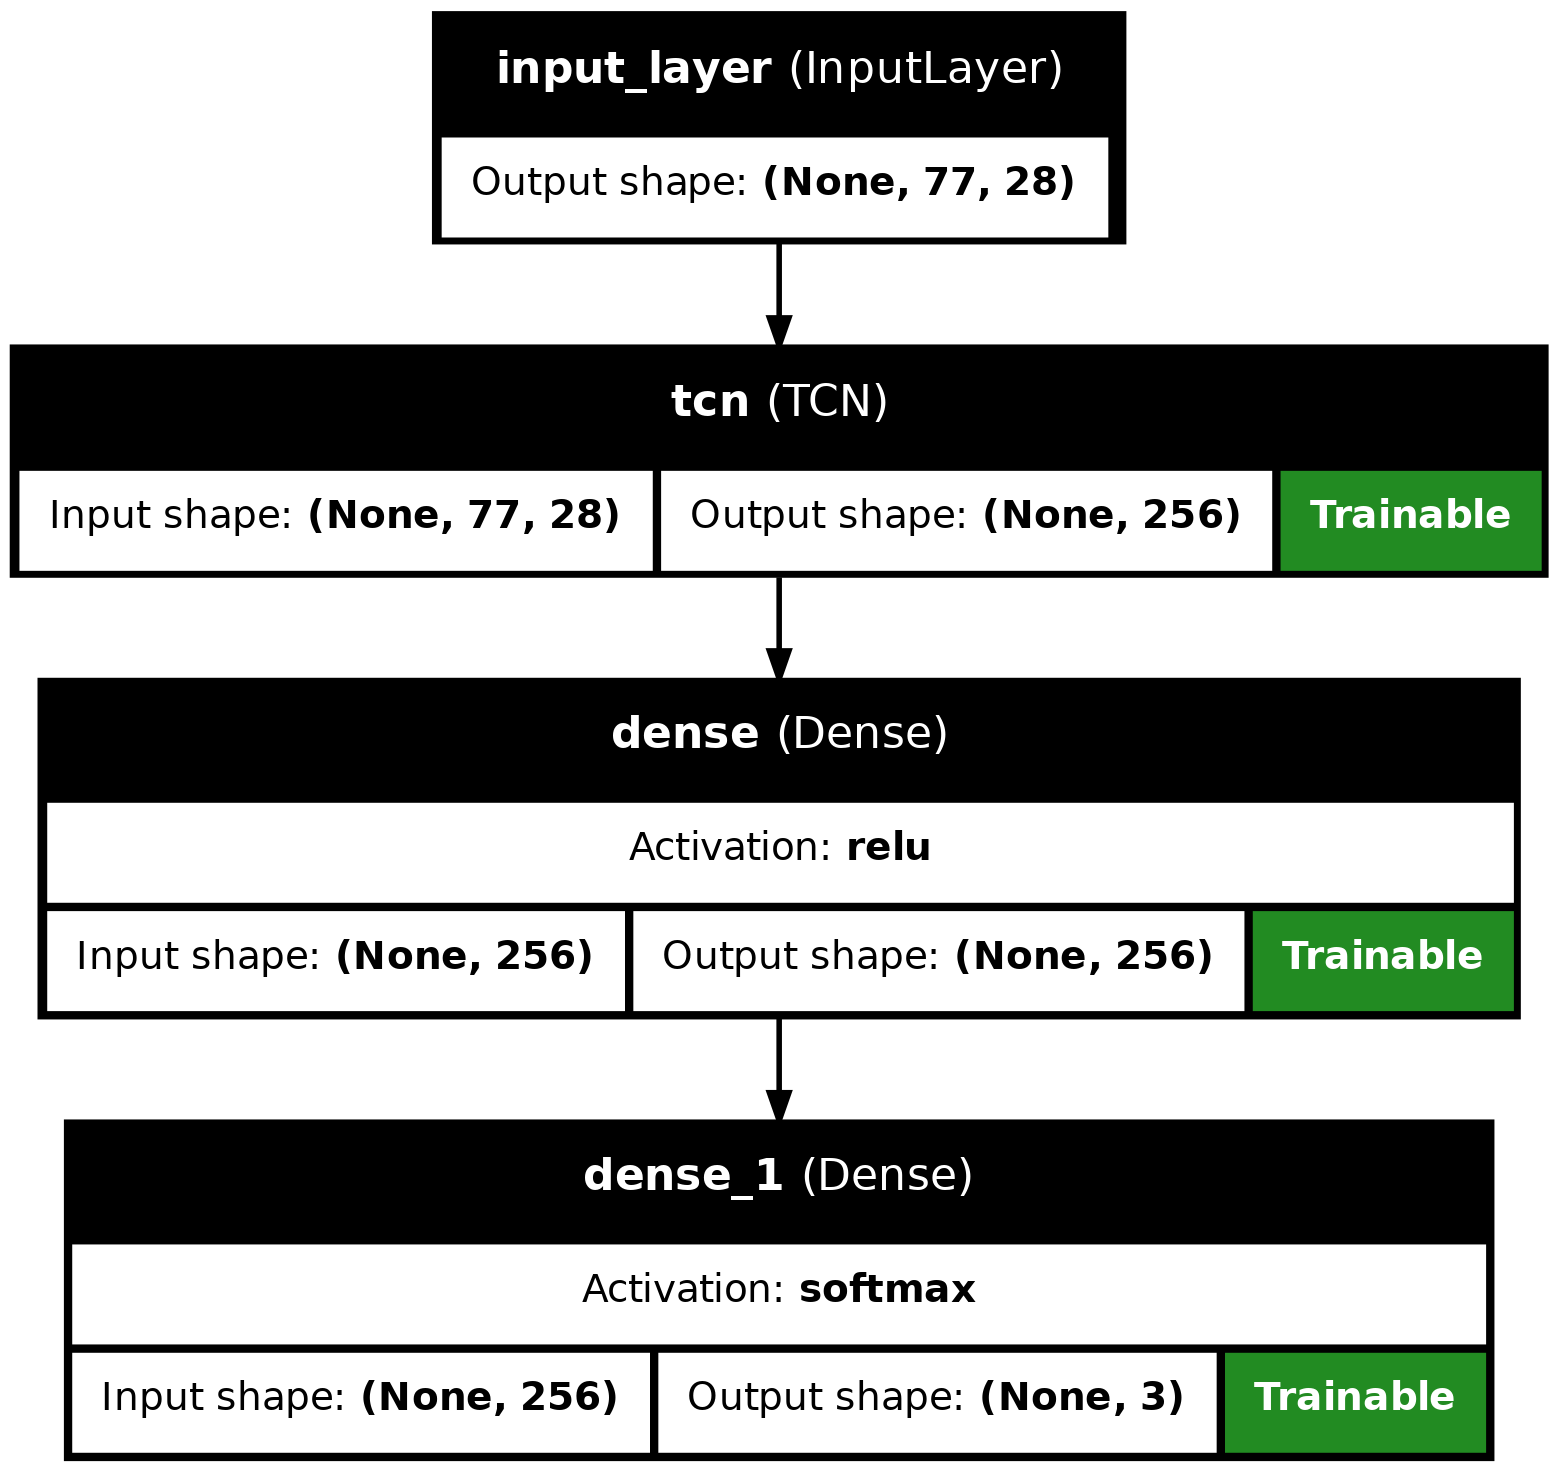

In [4]:
import keras
from tcn import TCN
from keras.utils import plot_model

plot_model(
    model,
    to_file="model_test2.png",
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=200,
    show_layer_activations=True,
    show_trainable=True,
)